In [32]:
import os
import joblib
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from openwakeword.utils import AudioFeatures
from pathlib import Path
from scipy.io import wavfile

In [33]:
def predict_on_features(model_path, input_features, step=1):
    # Load model
    import onnxruntime as ort
    sessionOptions = ort.SessionOptions()
    model = ort.InferenceSession(model_path, sess_options=sessionOptions, providers=["CPUExecutionProvider"])

    # Predict on features
    scores = []
    input_features = np.vstack(input_features)
    for i in tqdm(range(16, len(input_features), step), desc="Evaluating negatives"):
        sample = input_features[i-16:i]
        model_input = sample[None,]  # shape = (1, 16, 96)
        outputs = model.run(None, {'onnx::Flatten_0': model_input})
        scores.append(outputs[0][0][0])

    return scores

In [34]:
def predict_on_wavs(oww_model, clips, model_name, gain=1):
    positive_scores = []
    for clip in tqdm(clips, desc="Evaluating positives"):
        if isinstance(clip, str):
            with wave.open(clip, mode='rb') as f:
                data = np.frombuffer(f.readframes(f.getnframes()), dtype=np.int16)
                data = np.array(data, copy=True)  # Ensure it's writable
        elif isinstance(clip, np.ndarray):
            data = clip
        data *= gain
        scores = oww_model.predict_clip(data)
        scores = [i[model_name] for i in scores]
        positive_scores.append(max(scores))
    return positive_scores

In [35]:
def generate_embedding(wav_path):
    with wave.open(clip, mode='rb') as f:
        data = np.frombuffer(f.readframes(f.getnframes()), dtype=np.int16)
        data = np.array(data, copy=True)  # Ensure it's writable

In [36]:
# (get_false_positives is better)
# def get_false_activations(scores, threshold=.5, grouping_window=16):
#     """Counts false positives based on patience factor (corrected from 'get_false_activations' in metrics.py)
#     - grouping_window: adjacent features to consider under the same activation
#     """
#     n_fp = 0
#     patience = 0
#     scores = np.array(scores)
#     for score in scores:
#         if patience != 0:
#             patience -= 1
#             continue
#         else:
#             if score >= threshold:
#                 patience = grouping_window
#                 n_fp += 1
#     return n_fp

In [37]:
def get_far(scores, threshold=.5, clip_size=2, frames_per_clip=16, grouping_window=16):
    frames = len(scores)
    frames_per_hour = 3600 * 16000 / 1280
    hours = frames / frames_per_hour
    false_activations = get_false_positives(scores, threshold, grouping_window)
    return false_activations / hours

In [38]:
def get_models_from_folder(folder="F:/models/", wakeword="alexa", depth=0):
    folder_path = Path(folder)
    
    if depth is None:
        pattern = "**/*.onnx"  # Scan all subdirectories
    else:
        pattern = "*/" * depth + "*.onnx"  # Limit depth
        
    model_paths = [
        str(i) for i in folder_path.glob(pattern)
        if wakeword in str(i) and "hola-" + wakeword not in str(i)
    ]
    
    model_names = [os.path.splitext(os.path.basename(p))[0] for p in model_paths]
    return dict(zip(model_names, model_paths))

In [39]:
def get_yamls_from_folder(folder="F:/models/", wakeword="alexa", depth=0):
    folder_path = Path(folder)
    
    if depth is None:
        pattern = "**/*.yaml"  # Scan all subdirectories
    else:
        pattern = "*/" * depth + "*.yaml"  # Limit depth
    
    yaml_paths = [
        str(i) for i in folder_path.glob(pattern)
        if wakeword in str(i) and "hola-" + wakeword not in str(i)
    ]
    
    return yaml_paths

In [40]:
def evaluate_models(models, positive_clips, negative_features, wakeword, gain=1, results_folder="F:/results/"):
    
    print(f"Evaluating wake word: {wakeword}")

    if gain != 1:
        gain_results_folder = os.path.join(results_folder, f"gain+{gain}")
        if not os.path.isdir(gain_results_folder):
            os.mkdir(gain_results_folder)
            print(f"Created dir at {gain_results_folder}")
        results_folder = gain_results_folder

    for mdl_name, mdl_path in models.items():
        if wakeword in mdl_name:

            print(f"Evaluating {mdl_name}")
            
            positive_scores_file = f"{results_folder}/{mdl_name}_positive_scores.npy"
            negative_scores_file = f"{results_folder}/{mdl_name}_negative_scores.npy"
            
            if not os.path.exists(positive_scores_file):
                oww_mdl = openwakeword.Model(wakeword_models=[mdl_path])
                positive_scores = predict_on_wavs(oww_mdl, positive_clips, mdl_name, gain=gain)
                np.save(positive_scores_file, np.array(positive_scores))
                print(f"Saved positive results to {positive_scores_file}...")
            else:
                print(f"Skipping positive evaluation on {mdl_name}. ({positive_scores_file} already exists!)")

            if not os.path.exists(negative_scores_file):
                negative_scores = predict_on_features(mdl_path, negative_features)
                np.save(negative_scores_file, np.array(negative_scores))
                print(f"Saved negative results to {negative_scores_file}...")
            else:
                print(f"Skipping negative evaluation on {mdl_name}. ({negative_scores_file} already exists!)")
                

In [41]:
def plot_roc_comparison(models, wakeword, n_points=100, results_folder="F:/results", xlim=1, ylim=1, 
                         show_n_thresholds=0, devices=["temi", "phone", "maia"], ticks=5, fontsize=18):
    
    # Select devices
    device_subset = {"temi": 0, "phone": 1, "maia": 2}
    selected_devices = [device_subset[k] for k in devices]
    
    # Build plot
    plt.figure(figsize=(8,6))
    plt.title(f"{wakeword} model ROC on: " + ', '.join(devices), fontsize=fontsize)
    ths = np.logspace(-3, 0, n_points)

    for mdl_name, _ in tqdm(models.items()):
        if wakeword in mdl_name and "hola-" + wakeword not in mdl_name:
            try:
                pos = np.load(f"{results_folder}/{mdl_name}_positive_scores.npy")
                neg = np.load(f"{results_folder}/{mdl_name}_negative_scores.npy")
            except OSError:
                continue

            # Filter devices
            pos = np.hstack([val for i, val in enumerate(np.array_split(pos, 3)) if i in selected_devices])
            
            # DATA
            frr = [1 - sum(pos > th) / len(pos) for th in ths]
            far = [sum(neg > th) / (len(neg) / 45000) for th in ths]
            
            plt.plot(far, frr, label=mdl_name)

            if show_n_thresholds > 0:
                step = len(ths) // show_n_thresholds
                for i in range(0, len(ths), step):  # Annotate selected points
                    plt.annotate(f"{ths[i]:.4f}", (far[i], frr[i]), textcoords="offset points", 
                                 xytext=(10,20), ha='left', fontsize=fontsize-2, color="red",
                                 arrowprops=dict(arrowstyle="simple", color="red"))
        else:
            print(f"Skipping {mdl_name} since wakeword {wakeword} is being evaluated")
    
    plt.ylim(0, ylim)
    plt.xlim(0, xlim)
    plt.xlabel("False Accepts/Hour", fontsize=fontsize)
    plt.ylabel("False Reject Rate", fontsize=fontsize)
    plt.xticks(np.linspace(0, xlim, ticks), fontsize=fontsize)
    plt.yticks(np.linspace(0, ylim, ticks), fontsize=fontsize)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=fontsize)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.minorticks_on()
    plt.grid(True, which='minor', linestyle=':', linewidth=0.3)
    plt.show()


In [42]:
def plot_frr_comparison(models, wakeword, n_points=30, results_folder="F:/results"):
    
    thresholds = np.linspace(0, 1, num=n_points)
    
    plt.figure(figsize=(5,4))
    plt.title(f"{wakeword} model FRR")

    for mdl_name, _ in models.items():
        if wakeword in mdl_name:
            pos = np.load(f"{results_folder}/{mdl_name}_positive_scores.npy")
            frr = 1 - (np.array([sum(np.array(pos) > th) for th in thresholds]) / len(pos))
            plt.plot(thresholds, frr, label=mdl_name)

    plt.ylim(0, 1)
    plt.xlim(0,1)
    plt.xlabel("Threshold")
    plt.ylabel("FRR")
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.grid(True)
    plt.show()

In [43]:
def plot_far_comparison(models, wakeword, n_points=30, results_folder="F:/results", ylim=2):

    thresholds = np.linspace(0, 1, num=n_points)
    
    plt.figure(figsize=(5,4))
    plt.title(f"{wakeword} model FAR")

    for mdl_name, _ in models.items():
        if wakeword in mdl_name:
            neg = np.load(f"{results_folder}/{mdl_name}_negative_scores.npy")
            far = np.array([get_far(neg, threshold=th, grouping_window=1) for th in thresholds])
            plt.plot(thresholds, far, label=mdl_name)

    plt.ylim(0,ylim)
    plt.xlim(0,1)
    plt.ylabel("FAR (#/ h)")
    plt.xlabel("Threshold")
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.grid(True)
    plt.show()

In [13]:
def get_wavs_from_folders(folders, filter_word=""):
    wavs = []
    for folder in folders:
        wavs.extend([str(i) for i in Path(folder).glob("**/*.wav") if filter_word in str(i)])
    print(f"Loaded {len(wavs)} .wav audios")
    return wavs

In [2]:
n = 50000
folder = "F:/models/hola-ayud_00/hola-ayud"
pos_train = np.load(os.path.join(folder, "positive_features_train.npy"), mmap_mode='r')[:n].reshape(n, -1)
neg_train = np.load(os.path.join(folder, "negative_features_train.npy"), mmap_mode='r')[:n].reshape(n, -1)
pos_val = np.load(os.path.join(folder, "positive_features_test.npy"), mmap_mode='r')
neg_val = np.load(os.path.join(folder, "negative_features_test.npy"), mmap_mode='r')
tv3 = np.load(r"F:\data\train\NEGATIVE\tv3_train.npy", mmap_mode='r')[:10*n].reshape(10*n, -1)
acav = np.load(r"F:\data\train\NEGATIVE\openwakeword_features_ACAV100M_2000_hrs_16bit.npy", mmap_mode='r')[:10*n].reshape(10*n, -1)
podcasts = np.load(r"F:\data\train\NEGATIVE\openwakeword_features_podcasts_10000h_ca-es_ca_es-es.npy", mmap_mode='r')[:10*n].reshape(10*n, -1)

Xpos = pos_train
Xneg = np.vstack((tv3, neg_train, acav, podcasts))
ypos = np.ones(len(Xpos))
yneg = np.zeros(len(Xneg))

X = np.vstack((Xpos, Xneg))
y = np.concatenate((ypos, yneg))

print(X.shape, y.shape)

(1600000, 1536) (1600000,)


In [179]:
# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Apply PCA
pca = PCA(n_components=100)
X_train_pca = pca.fit_transform(X_train)

# Step 4: Train a classifier (Random Forest in this case)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_pca, y_train)

# Step 5: Evaluate
X_test_pca = pca.transform(X_test)
y_pred = clf.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_pred)
print(f"Classification Accuracy: {accuracy:.4f}")

Classification Accuracy: 0.9943


In [184]:
joblib.dump(pca, os.path.join("F:/models/hola-ayud_00", "hola-ayud_pca_00.pkl"))  # Save the PCA model

['F:/models/hola-ayud_00\\hola-ayud_pca_00.pkl']

In [188]:
joblib.dump(clf, os.path.join("F:/models/hola-ayud_00", "hola-ayud_rf_00.pkl"))

['F:/models/hola-ayud_00\\hola-ayud_rf_00.pkl']

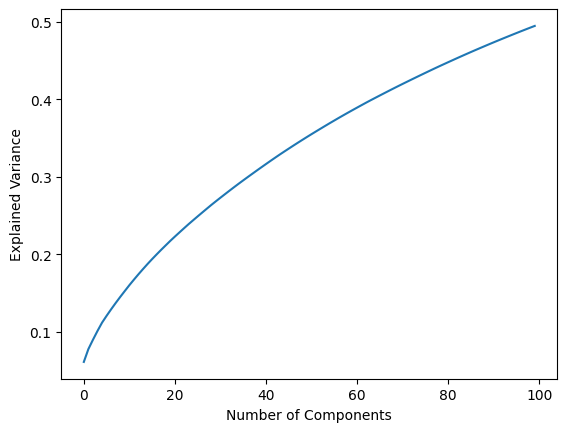

In [180]:
explained_variance = np.cumsum(pca.explained_variance_ratio_)
import matplotlib.pyplot as plt
plt.plot(explained_variance)
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")
plt.show()

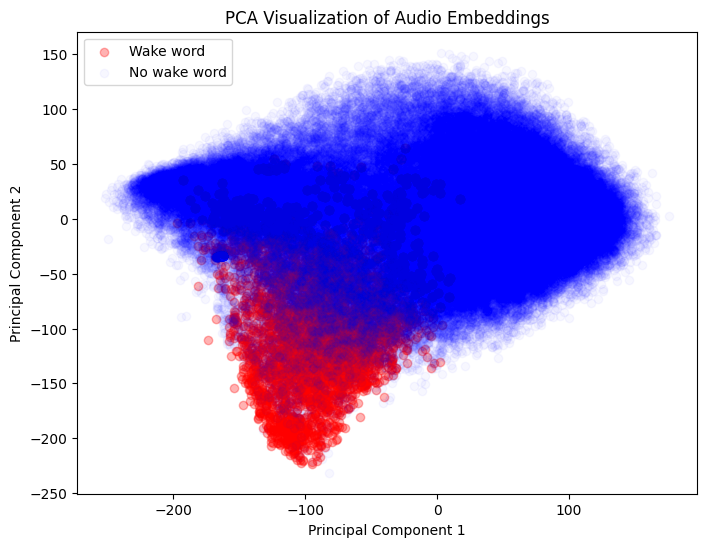

In [201]:
# Step 2: Create a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[y_train == 1][::10, 0], X_train_pca[y_train == 1][::10, 1], c='red', alpha=0.3, label="Wake word")
plt.scatter(X_train_pca[y_train == 0][::10, 0], X_train_pca[y_train == 0][::10, 1], c='blue', alpha=0.03, label="No wake word")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Audio Embeddings')
plt.legend()
plt.show()

C:\Users\gbartag\AppData\Local\Temp\ipykernel_34104\2474050230.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


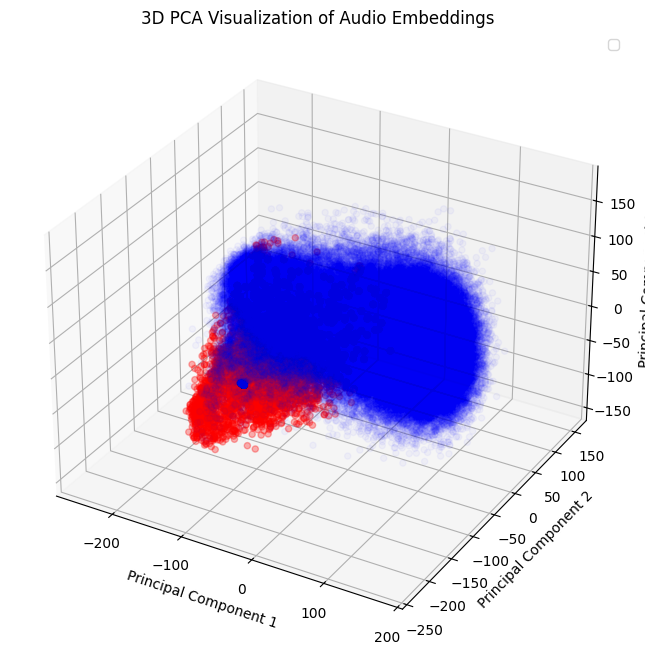

In [202]:
# Step 2: Create a 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with class labels (c=y for coloring based on labels)
ax.scatter(X_train_pca[y_train == 1][::10, 0], X_train_pca[y_train == 1][::10, 1], X_train_pca[y_train == 1][::10, 2], c='red', alpha=0.3, label="Wake word")
ax.scatter(X_train_pca[y_train == 0][::10, 0], X_train_pca[y_train == 0][::10, 1], X_train_pca[y_train == 0][::10, 2], c='blue', alpha=0.03, label="No wake word")

# Labels and title
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('3D PCA Visualization of Audio Embeddings')

# Show the plot
plt.legend()
plt.show()

## TESTS

In [3]:
F = AudioFeatures()

In [4]:
def get_wavs_from_folders(folders, filter_word=""):
    wavs = []
    for folder in folders:
        wavs.extend([str(i) for i in Path(folder).glob("**/*.wav") if filter_word in str(i)])
    print(f"Loaded {len(wavs)} .wav audios")
    return wavs

In [6]:
pca_test = joblib.load(os.path.join("F:/models/hola-ayud_00/pca", "hola-ayud_pca_00.pkl"))
clf_test = joblib.load(os.path.join("F:/models/hola-ayud_00/pca", "hola-ayud_rf_00.pkl"))

In [7]:
positive_scores = []
for audio_path in get_wavs_from_folders([r"F:\data\test\hola-ayud\wav"]):
    sr, data = wavfile.read(audio_path)
    embeddings = F._get_embeddings(data)
    windows = [embeddings[i:i+16].reshape(16*96) for i in range(0, len(embeddings) - 15)]
    pca_embeddings = pca_test.transform(windows)
    scores = clf_test.predict_proba(pca_embeddings)[:,1]
    positive_scores.append(max(scores))
positive_scores = np.array(positive_scores)

Loaded 375 .wav audios


In [45]:
positive_scores.shape

(375,)

In [11]:
tv3_test = np.load("F:/data/test/NEGATIVE/tv3_test.npy")
wham_tt = np.load("F:/data/test/NEGATIVE/wham_tt.npy")
dipco_eval_ch1 = np.load("F:/data/test/NEGATIVE/dipco_eval_ch1.npy")
# podcasts_test = np.memmap("F:/data/test/NEGATIVE/openwakeword_features_podcasts_1000h_ca.npy", dtype=np.float32, shape=(1800000, 16, 96))
# podcasts_train = np.memmap("F:/data/train/NEGATIVE/openwakeword_features_podcasts_10000h_ca-es_ca_es-es.npy", dtype=np.float32, shape=(18000000, 16, 96))
negative_features = np.vstack((tv3_test, wham_tt, dipco_eval_ch1)) #, podcasts_train[1:18000]))  # shape: (samples, 16, 96)

In [12]:
negative_features.shape

(30686, 16, 96)

In [13]:
negative_scores = []
windows = negative_features.reshape(-1, 16*96)
pca_embeddings = pca_test.transform(windows)
negative_scores = clf_test.predict_proba(pca_embeddings)[:,1]

In [14]:
windows.shape

(30686, 1536)

In [44]:
negative_scores.shape

(30686,)

In [46]:
results_folder="F:/results/"
mdl_name="PCA_RF"

positive_scores_file = f"{results_folder}/{mdl_name}_positive_scores.npy"
negative_scores_file = f"{results_folder}/{mdl_name}_negative_scores.npy"

if not os.path.exists(positive_scores_file):
    np.save(positive_scores_file, np.array(positive_scores))

if not os.path.exists(negative_scores_file):
    np.save(negative_scores_file, np.array(negative_scores))

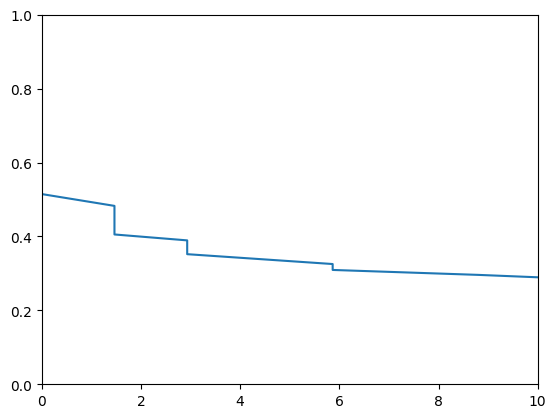

In [30]:
import matplotlib.pyplot as plt
plt.figure()
frr = []
FAhour = []
for th in np.logspace(-3, 0, 100):
    frr.append(1 - sum(positive_scores > th) / len(positive_scores))
    FAhour.append(sum(negative_scores > th) / (len(negative_scores)) * 45000)
    
plt.plot(FAhour, frr)
plt.ylim(0, 1)
plt.xlim(0, 10)
plt.show()

In [ ]:
def plot_roc_comparison(models, wakeword, n_points=100, results_folder="F:/results", xlim=1, ylim=1, 
                         show_n_thresholds=0, devices=["temi", "phone", "maia"], ticks=5, fontsize=18):
    
    # Select devices
    device_subset = {"temi": 0, "phone": 1, "maia": 2}
    selected_devices = [device_subset[k] for k in devices]
    
    # Build plot
    plt.figure(figsize=(8,6))
    plt.title(f"{wakeword} model ROC on: " + ', '.join(devices), fontsize=fontsize)
    ths = np.logspace(-3, 0, n_points)

    for mdl_name, _ in tqdm(models.items()):
        if wakeword in mdl_name and "hola-" + wakeword not in mdl_name:
            try:
                pos = np.load(f"{results_folder}/{mdl_name}_positive_scores.npy")
                neg = np.load(f"{results_folder}/{mdl_name}_negative_scores.npy")
            except OSError:
                continue

            # Filter devices
            pos = np.hstack([val for i, val in enumerate(np.array_split(pos, 3)) if i in selected_devices])
            
            # DATA
            frr = [1 - sum(pos > th) / len(pos) for th in ths]
            far = [sum(neg > th) / (len(neg) / 45000) for th in ths]
            
            plt.plot(far, frr, label=mdl_name)

            if show_n_thresholds > 0:
                step = len(ths) // show_n_thresholds
                for i in range(0, len(ths), step):  # Annotate selected points
                    plt.annotate(f"{ths[i]:.4f}", (far[i], frr[i]), textcoords="offset points", 
                                 xytext=(10,20), ha='left', fontsize=fontsize-2, color="red",
                                 arrowprops=dict(arrowstyle="simple", color="red"))
        else:
            print(f"Skipping {mdl_name} since wakeword {wakeword} is being evaluated")
    
    plt.ylim(0, ylim)
    plt.xlim(0, xlim)
    plt.xlabel("False Accepts/Hour", fontsize=fontsize)
    plt.ylabel("False Reject Rate", fontsize=fontsize)
    plt.xticks(np.linspace(0, xlim, ticks), fontsize=fontsize)
    plt.yticks(np.linspace(0, ylim, ticks), fontsize=fontsize)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=fontsize)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.minorticks_on()
    plt.grid(True, which='minor', linestyle=':', linewidth=0.3)
    plt.show()


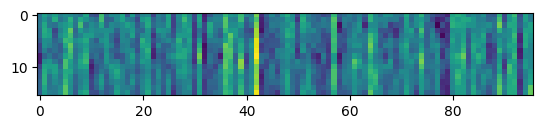

In [103]:
plt.imshow(negative_features[1])

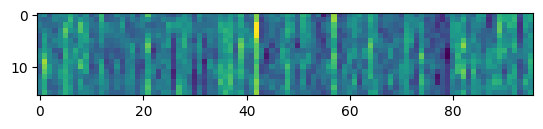

In [104]:
plt.imshow(negative_features[2])

Loaded 375 .wav audios


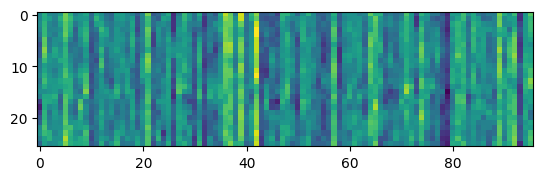

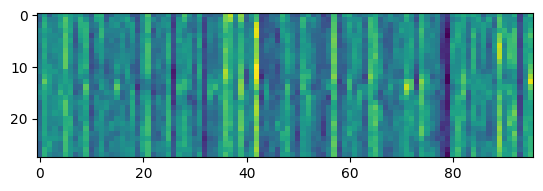

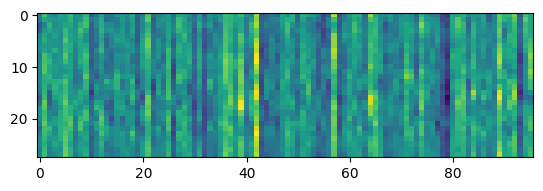

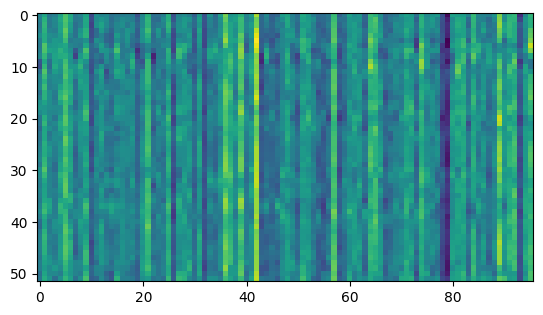

In [111]:
c = 0
for audio_path in get_wavs_from_folders([r"F:\data\test\hola-ayud\wav"]):
    c+=1
    if c==8:
        break
    if c%2 == 0:
        continue
    sr, data = wavfile.read(audio_path)
    embeddings = F._get_embeddings(data)
    plt.figure()
    plt.imshow(embeddings)